# 02 — Exploratory Data Analysis (EDA)
## Smart Expense Intelligence Dashboard
**Goal:** Uncover spending patterns, trends, and insights across categories, time, merchants, and customer demographics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Plot styling
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Create screenshots folder if not exists
os.makedirs('../screenshots', exist_ok=True)

# Load clean data
df = pd.read_csv('../data/clean_transactions.csv', parse_dates=['date'])

print(f"✅ Data loaded: {df.shape}")
df.head(3)

✅ Data loaded: (50000, 18)


,customer_id,name,surname,gender,birthdate,transaction_amount,date,merchant_name,category,year,month,month_name,quarter,week_number,day_of_week,is_weekend,age,is_outlier
0,752858,Sean,Rodriguez,F,2002-10-20,35.47,2023-04-03,Smith-Russell,Cosmetic,2023,4,April,2,14,Monday,0,20.0,0
1,26381,Michelle,Phelps,Unknown,1985-10-24,2552.72,2023-07-17,"Peck, Spence And Young",Travel,2023,7,July,3,29,Monday,0,38.0,1
2,305449,Jacob,Williams,M,1981-10-25,115.97,2023-09-20,Steele Inc,Clothing,2023,9,September,3,38,Wednesday,0,42.0,0


In [2]:
print("=== SPENDING OVERVIEW ===")
print(f"Date range        : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Total transactions: {len(df):,}")
print(f"Total spend       : ₹{df['transaction_amount'].sum():,.2f}")
print(f"Avg per transaction: ₹{df['transaction_amount'].mean():,.2f}")
print(f"Highest transaction: ₹{df['transaction_amount'].max():,.2f}")
print(f"Lowest transaction : ₹{df['transaction_amount'].min():,.2f}")
print(f"\nCategories : {df['category'].unique().tolist()}")
print(f"Gender split:\n{df['gender'].value_counts()}")

=== SPENDING OVERVIEW ===
Date range        : 2023-01-01 → 2023-10-14
Total transactions: 50,000
Total spend       : ₹22,105,961.97
Avg per transaction: ₹442.12
Highest transaction: ₹2,999.88
Lowest transaction : ₹5.01

Categories : ['Cosmetic', 'Travel', 'Clothing', 'Electronics', 'Restaurant', 'Market']
Gender split:
gender
F          22713
M          22240
Unknown     5047
Name: count, dtype: int64


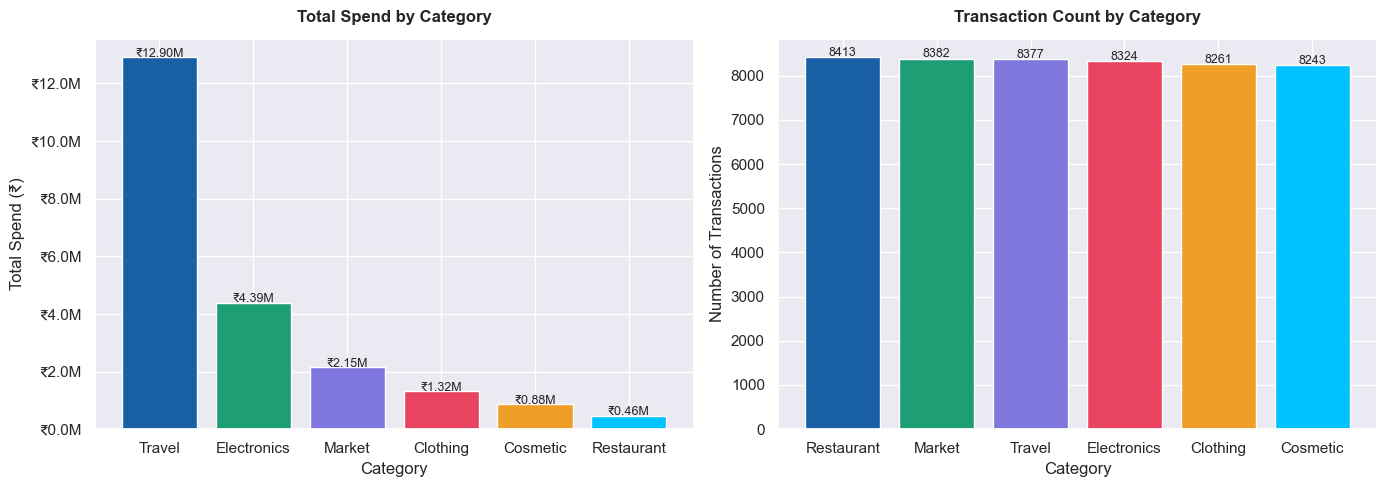

✅ Chart saved → screenshots/01_category_spend.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data
cat_spend = df.groupby('category')['transaction_amount'].sum().sort_values(ascending=False)
cat_count = df.groupby('category')['transaction_amount'].count().sort_values(ascending=False)

colors = ['#185FA5','#1D9E75','#7F77DD','#E94560','#EF9F27','#00C2FF']

# Chart 1a — Total spend by category
axes[0].bar(cat_spend.index, cat_spend.values, color=colors)
axes[0].set_title('Total Spend by Category', fontweight='bold', pad=12)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Spend (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
for i, v in enumerate(cat_spend.values):
    axes[0].text(i, v + 10000, f'₹{v/1e6:.2f}M', ha='center', fontsize=9)

# Chart 1b — Transaction count by category
axes[1].bar(cat_count.index, cat_count.values, color=colors)
axes[1].set_title('Transaction Count by Category', fontweight='bold', pad=12)
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of Transactions')
for i, v in enumerate(cat_count.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../screenshots/01_category_spend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/01_category_spend.png")

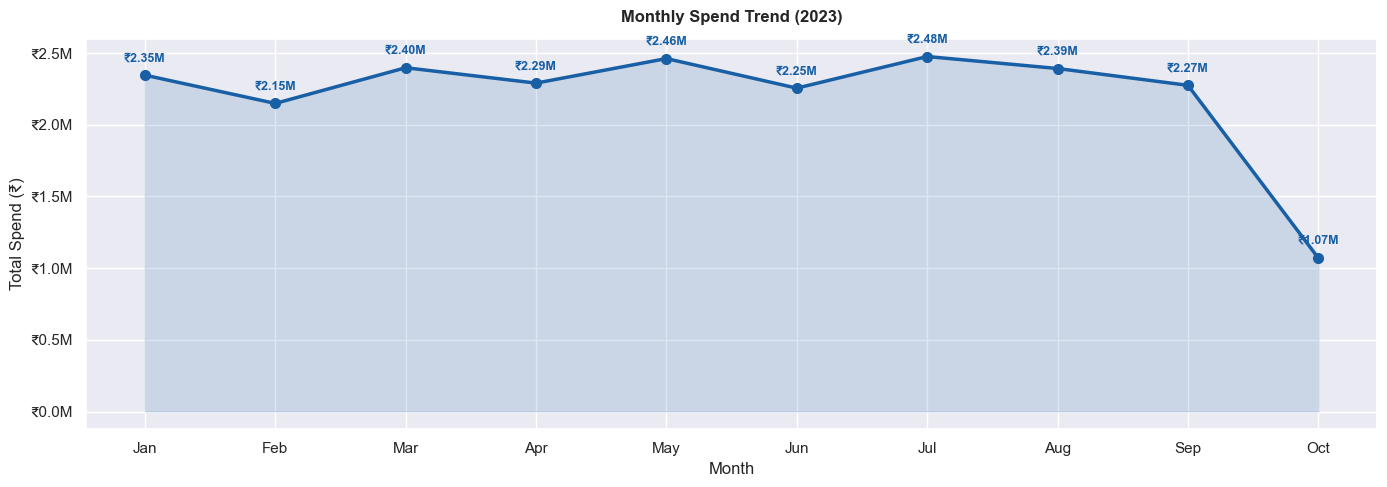

✅ Chart saved → screenshots/02_monthly_trend.png


In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

monthly = df.groupby(['year', 'month', 'month_name'])['transaction_amount'].sum().reset_index()
monthly = monthly.sort_values(['year', 'month'])
monthly['label'] = monthly['month_name'].str[:3]

ax.plot(monthly['label'], monthly['transaction_amount'], 
        color='#185FA5', linewidth=2.5, marker='o', markersize=7)
ax.fill_between(monthly['label'], monthly['transaction_amount'], 
                alpha=0.15, color='#185FA5')

# Annotate each point
for _, row in monthly.iterrows():
    ax.annotate(f"₹{row['transaction_amount']/1e6:.2f}M",
                xy=(row['label'], row['transaction_amount']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='#185FA5', fontweight='bold')

ax.set_title('Monthly Spend Trend (2023)', fontweight='bold', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Total Spend (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('../screenshots/02_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/02_monthly_trend.png")

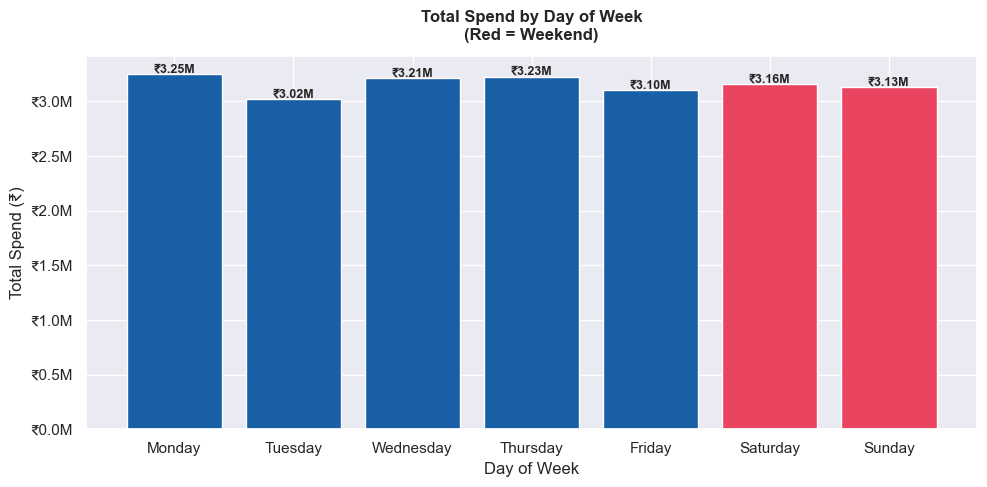

✅ Chart saved → screenshots/03_day_of_week.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# Order days correctly
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_spend = df.groupby('day_of_week')['transaction_amount'].sum().reindex(day_order)

colors = ['#E94560' if d in ['Saturday','Sunday'] else '#185FA5' for d in day_order]

bars = ax.bar(day_spend.index, day_spend.values, color=colors)

# Annotate
for bar, val in zip(bars, day_spend.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15000,
            f'₹{val/1e6:.2f}M', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Total Spend by Day of Week\n(Red = Weekend)', fontweight='bold', pad=12)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Total Spend (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('../screenshots/03_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/03_day_of_week.png")

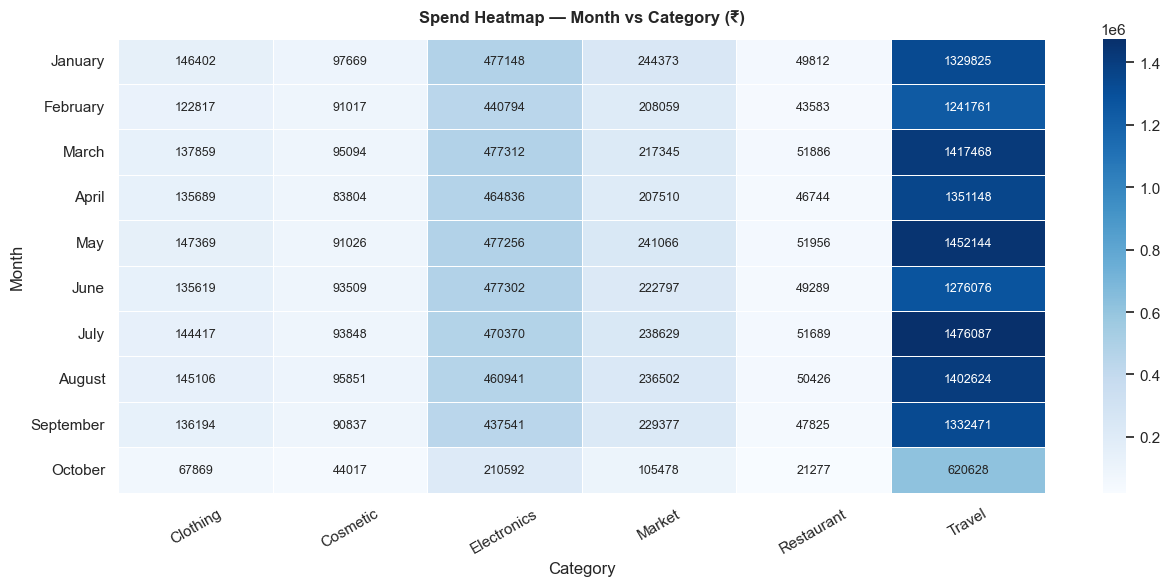

✅ Chart saved → screenshots/04_heatmap.png


In [6]:
fig, ax = plt.subplots(figsize=(13, 6))

# Pivot table
heatmap_data = df.groupby(['month_name', 'category'])['transaction_amount'].sum().unstack()

# Reorder months
month_order = ['January','February','March','April','May',
               'June','July','August','September','October']
heatmap_data = heatmap_data.reindex(month_order)

sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.0f',
            cmap='Blues',
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 9})

ax.set_title('Spend Heatmap — Month vs Category (₹)', fontweight='bold', pad=12)
ax.set_xlabel('Category')
ax.set_ylabel('Month')
plt.xticks(rotation=30)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../screenshots/04_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/04_heatmap.png")

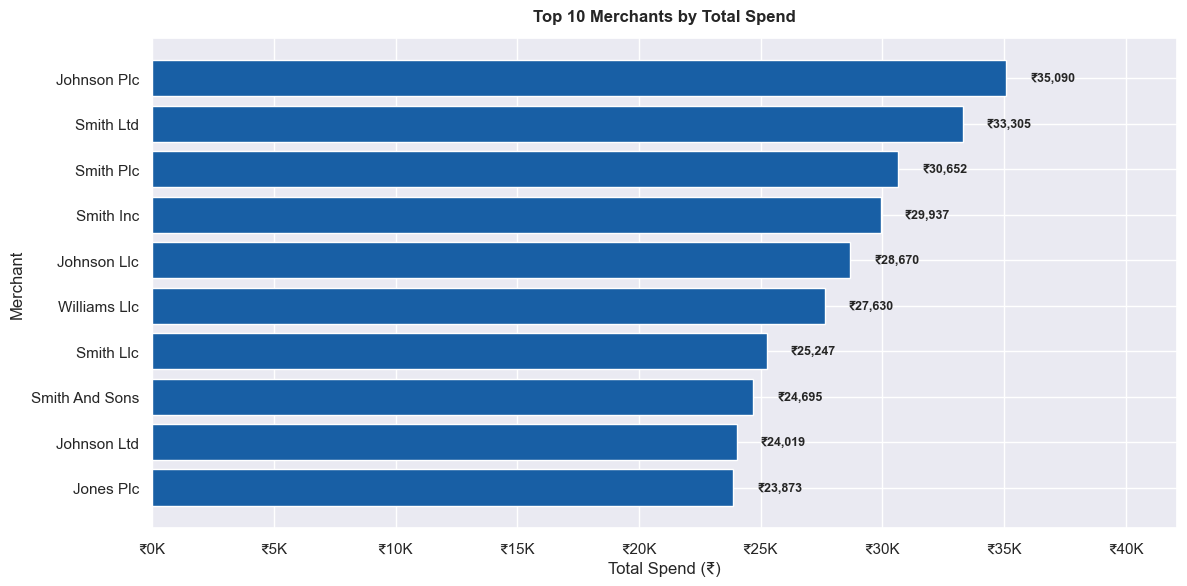

✅ Chart saved → screenshots/05_top_merchants.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

top_merchants = (df.groupby('merchant_name')['transaction_amount']
                 .sum()
                 .sort_values(ascending=True)
                 .tail(10))

bars = ax.barh(top_merchants.index, top_merchants.values, color='#185FA5')

# Annotate
for bar, val in zip(bars, top_merchants.values):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'₹{val:,.0f}', va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 10 Merchants by Total Spend', fontweight='bold', pad=12)
ax.set_xlabel('Total Spend (₹)')
ax.set_ylabel('Merchant')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e3:.0f}K'))
ax.set_xlim(0, top_merchants.max() * 1.2)

plt.tight_layout()
plt.savefig('../screenshots/05_top_merchants.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/05_top_merchants.png")

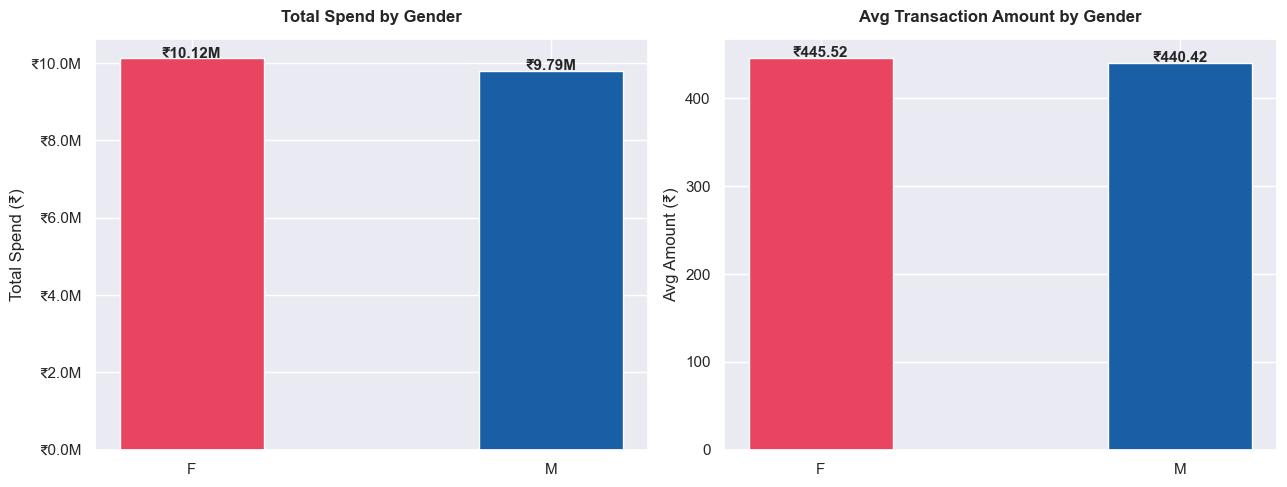

✅ Chart saved → screenshots/06_gender_spend.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Filter out Unknown for cleaner analysis
df_gender = df[df['gender'] != 'Unknown']

# Chart 6a — Total spend by gender
gender_spend = df_gender.groupby('gender')['transaction_amount'].sum()
colors = ['#E94560', '#185FA5']
axes[0].bar(gender_spend.index, gender_spend.values, color=colors, width=0.4)
axes[0].set_title('Total Spend by Gender', fontweight='bold', pad=12)
axes[0].set_ylabel('Total Spend (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
for i, v in enumerate(gender_spend.values):
    axes[0].text(i, v + 20000, f'₹{v/1e6:.2f}M', ha='center', fontweight='bold')

# Chart 6b — Avg transaction amount by gender
gender_avg = df_gender.groupby('gender')['transaction_amount'].mean()
axes[1].bar(gender_avg.index, gender_avg.values, color=colors, width=0.4)
axes[1].set_title('Avg Transaction Amount by Gender', fontweight='bold', pad=12)
axes[1].set_ylabel('Avg Amount (₹)')
for i, v in enumerate(gender_avg.values):
    axes[1].text(i, v + 1, f'₹{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/06_gender_spend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/06_gender_spend.png")

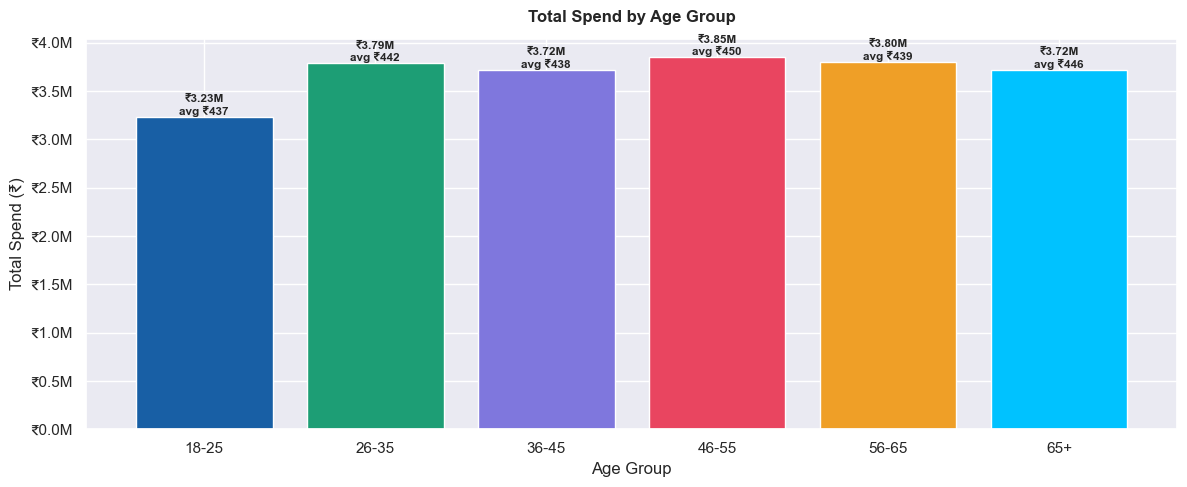

✅ Chart saved → screenshots/07_age_group_spend.png


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

# Create age bins
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

age_spend = df.groupby('age_group', observed=True)['transaction_amount'].sum()
age_count = df.groupby('age_group', observed=True)['transaction_amount'].count()
age_avg   = df.groupby('age_group', observed=True)['transaction_amount'].mean()

colors = ['#185FA5','#1D9E75','#7F77DD','#E94560','#EF9F27','#00C2FF']
bars = ax.bar(age_spend.index.astype(str), age_spend.values, color=colors)

for bar, val, avg in zip(bars, age_spend.values, age_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
            f'₹{val/1e6:.2f}M\navg ₹{avg:.0f}',
            ha='center', fontsize=8.5, fontweight='bold')

ax.set_title('Total Spend by Age Group', fontweight='bold', pad=12)
ax.set_xlabel('Age Group')
ax.set_ylabel('Total Spend (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('../screenshots/07_age_group_spend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/07_age_group_spend.png")

C:\Users\HARSHAL\AppData\Local\Temp\ipykernel_20012\1125514861.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='category', y='transaction_amount',


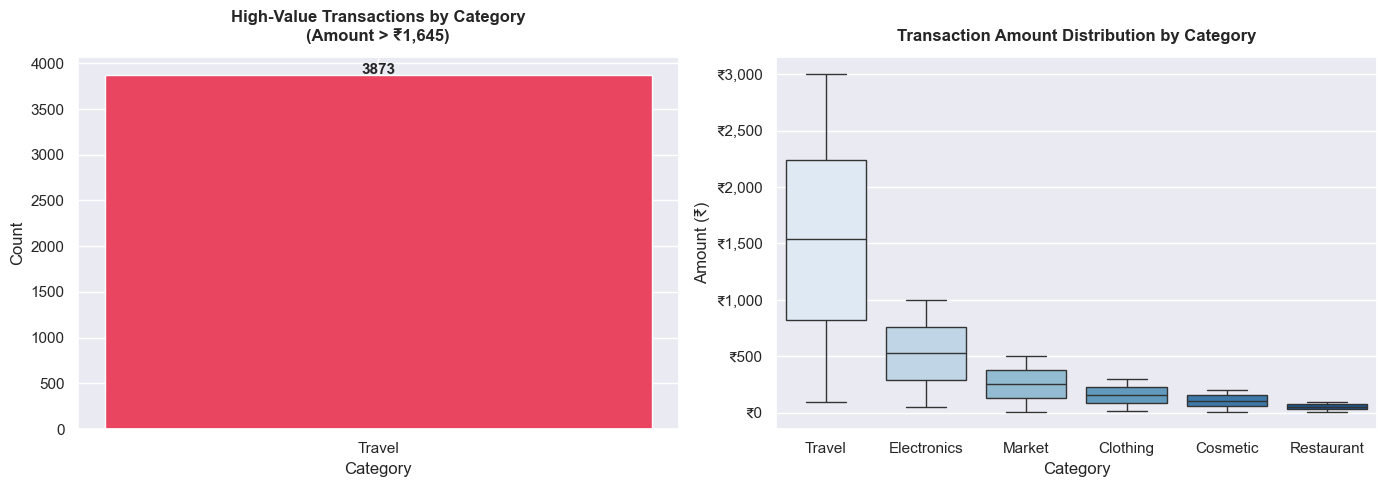

✅ Chart saved → screenshots/08_outliers.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 8a — Outlier count by category
outlier_cat = df[df['is_outlier']==1].groupby('category').size().sort_values(ascending=False)
axes[0].bar(outlier_cat.index, outlier_cat.values, color='#E94560')
axes[0].set_title('High-Value Transactions by Category\n(Amount > ₹1,645)', fontweight='bold', pad=12)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
for i, v in enumerate(outlier_cat.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Chart 8b — Boxplot of transaction amount by category
df_box = df[['category','transaction_amount']].copy()
cat_order = df.groupby('category')['transaction_amount'].median().sort_values(ascending=False).index
sns.boxplot(data=df_box, x='category', y='transaction_amount',
            order=cat_order, palette='Blues', ax=axes[1])
axes[1].set_title('Transaction Amount Distribution by Category', fontweight='bold', pad=12)
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Amount (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.tight_layout()
plt.savefig('../screenshots/08_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/08_outliers.png")

In [13]:
print("=" * 55)
print("   EDA COMPLETE — KEY INSIGHTS SUMMARY")
print("=" * 55)

total = df['transaction_amount'].sum()
top_cat = df.groupby('category')['transaction_amount'].sum().idxmax()
top_cat_pct = df.groupby('category')['transaction_amount'].sum().max() / total * 100
top_day = df.groupby('day_of_week')['transaction_amount'].sum().idxmax()
top_age = df.groupby('age_group', observed=True)['transaction_amount'].sum().idxmax()

print(f"""
1. TOTAL SPEND    : ₹{total:,.2f} across 50,000 transactions
2. TOP CATEGORY   : {top_cat} dominates at {top_cat_pct:.1f}% of total spend
                    — driven entirely by high ticket size, not frequency
3. OUTLIERS       : All 3,873 high-value transactions (>₹1,645)
                    belong exclusively to Travel
4. RESTAURANT     : Most frequent category (8,413 txns) but
                    lowest total spend — low avg ticket of ~₹55
5. WEEKDAY SPEND  : {top_day} is peak spend day —
                    no significant weekend spike observed  
6. TOP AGE GROUP  : {top_age} spends the most (₹3.85M)
                    but avg ticket size is consistent across all ages
7. GENDER         : Female spend (₹10.12M) slightly higher than
                    Male (₹9.79M) — driven by frequency not ticket size
8. OCTOBER        : Incomplete month (14 days only) —
                    exclude from trend comparisons
""")
print("=" * 55)
print("Next → 03_sql_analysis.ipynb")
print("=" * 55)

   EDA COMPLETE — KEY INSIGHTS SUMMARY

1. TOTAL SPEND    : ₹22,105,961.97 across 50,000 transactions
2. TOP CATEGORY   : Travel dominates at 58.4% of total spend
                    — driven entirely by high ticket size, not frequency
3. OUTLIERS       : All 3,873 high-value transactions (>₹1,645)
                    belong exclusively to Travel
4. RESTAURANT     : Most frequent category (8,413 txns) but
                    lowest total spend — low avg ticket of ~₹55
5. WEEKDAY SPEND  : Monday is peak spend day —
                    no significant weekend spike observed  
6. TOP AGE GROUP  : 46-55 spends the most (₹3.85M)
                    but avg ticket size is consistent across all ages
7. GENDER         : Female spend (₹10.12M) slightly higher than
                    Male (₹9.79M) — driven by frequency not ticket size
8. OCTOBER        : Incomplete month (14 days only) —
                    exclude from trend comparisons

Next → 03_sql_analysis.ipynb
